# Week 4 Analysis - What irregular activity occurred on r/place?

Identify the major buckets of irregular activity; meaning pixels not placed by regular human users. Your final analysis should consist of a neatly formatted analysis. For each bucket of activity, you should include:

1. Describe in human terms of what the activity is

2. Give several concrete examples of the activity as it happened in r/place. Visualizations should be used here.

3. Link to a python script that detects the described activity and give a short human description of your detection mechanism

In [58]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter
import datetime

PARQUET_PATH = "../2022_place_canvas_history.parquet"

### Let's start with creating a small animation of pixel placements during a given timeframe.

In [128]:
def hex_to_rgb(h: str):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16)/255.0 for i in (0, 2, 4))

def local(xmin, ymin, x, y):
    return x - xmin, y - ymin

def createGif(xmin: int, xmax: int, ymin: int , ymax: int, 
              df: pd.DataFrame, bins: int = 100, 
              file: str = None, 
              fps: int = 10, dt: int = 50):
    
    if (not file):
        file = f"rplace_{xmin}_{xmax}_{ymin}_{ymax}.gif"
    width = xmax - xmin + 1
    height = ymax - ymin + 1

    canvas = np.ones((height, width, 3))

    time_bin = bins

    df["rgb"] = df["pixel_color"].apply(hex_to_rgb)

    df["frame"] = (df["timestamp_epoch"] // time_bin)

    groups = list(df.groupby("frame"))

    fig, ax = plt.subplots()
    img = ax.imshow(canvas)
    ax.axis("off")

    def update(frame):
        _, chunk = groups[frame]

        for _, row in chunk.iterrows():
            x2 = row['x2'] if not pd.isna(row.get('x2', np.nan)) else row['x1']
            y2 = row['y2'] if not pd.isna(row.get('y2', np.nan)) else row['y1']

            x_start = min(row['x1'], x2)
            x_end = max(row['x1'], x2)

            y_start = min(row['y1'], y2)
            y_end = max(row['y1'], y2)

            x_start, y_start = local(xmin, ymin, x_start, y_start)
            x_end, y_end = local(xmin, ymin, x_end, y_end)

            xs = np.arange(x_start, x_end + 1)
            ys = np.arange(y_start, y_end + 1)

            xs = xs[(xs >= 0) & (xs < canvas.shape[1])]
            ys = ys[(ys >= 0) & (ys < canvas.shape[0])]
            
            X, Y = np.meshgrid(xs, ys)

            xs_flat = X.ravel()
            ys_flat = Y.ravel()


            canvas[ys_flat, xs_flat] = row["rgb"]

        img.set_data(canvas)
        return [img]

    ani = FuncAnimation(
        fig,
        update,
        frames=len(groups),
        interval=dt,
        blit=False
    )

    ani.save(file, writer="pillow", fps=fps)

In [ ]:
# Creating gif usage

xmin, ymin = 0, 0
xmax, ymax = 500, 500

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        pixel_color,
        x1,
        y1,
        x2,
        y2
    FROM
        '{PARQUET_PATH}'
    WHERE
        x1 >= {xmin} AND x1 <= {xmax} AND
        y1 >= {ymin} AND y1 <= {ymax}
    ORDER BY
        timestamp ASC
    LIMIT 100000
"""
df = duckdb.query(query).df()

createGif(xmin, xmax, ymin, ymax, df, fps=5)

## Admin Users

There are 19 distinct admin placements. We classify these as pixels that were placed but their coordinate field contained 4 numbers instead of the usual 2.

The assumption here is that these 4 numbers correspond to the vertices of a rectangle, likely being used to censor other pixels.

In [ ]:
# Getting all admin users
query = f"""
    SELECT
        *
    FROM
        '{PARQUET_PATH}'
    WHERE
        x2 IS NOT NULL
    ORDER BY timestamp ASC
"""

duckdb.query(query)

### Creating gifs of all admin rectangle placements

In [ ]:
query = f"""
    SELECT
        *
    FROM
        '{PARQUET_PATH}'
    WHERE
        x2 IS NOT NULL
    ORDER BY timestamp ASC
"""

admins = duckdb.query(query).df()

dr = 100

for i, data in admins.iterrows():
    x1, x2 = data['x1'], data['x2']
    y1, y2 = data['y1'], data['y2']
    
    center = data['timestamp']
    xmin, xmax = max(0, min(x1, x2) - dr), max(x1, x2) + dr
    ymin, ymax = max(0, min(y1, y2) - dr), max(y1, y2) + dr

    query = f"""
        SELECT
            user_id,
            EPOCH(timestamp) AS timestamp_epoch,
            pixel_color,
            x1,x2,y1,y2
        FROM
            '{PARQUET_PATH}'
        WHERE
            timestamp 
                BETWEEN 
                    (TIMESTAMP '{center}' - INTERVAL 30 MINUTES) AND 
                    (TIMESTAMP '{center}' + INTERVAL 30 MINUTES)
                AND
            x1 >= {xmin} AND (x2 <= {xmax} OR x2 IS NULL) AND
            y1 >= {ymin} AND (y2 <= {ymax} OR x2 IS NULL)
        ORDER BY
            timestamp ASC
    """

    df = duckdb.query(query).df()

    file_name = f"rplace_{xmin}_{xmax}_{ymin}_{ymax}_{i}.gif"
    createGif(xmin, xmax, ymin, ymax, df, file=file_name, fps=5, dt=200)



## Bots

In [159]:
# First type of bot:
#   A single user placing pixels on even/constant intervals (Bonus points if the same location/color)

CD = 60 * 5 # 60 * 5 minutes
BOT_THRESH = 5
query = f"""
    WITH
        user_intervals AS (
            SELECT
                user_id,
                EPOCH(timestamp) - LAG(EPOCH(timestamp)) OVER (PARTITION BY user_id ORDER BY timestamp ASC) AS interval
            FROM
                '{PARQUET_PATH}'
        ),
        interval_summary AS (
            SELECT
                user_id,
                COUNT(*) AS freq,
                AVG(interval) AS avg_interval,
                STDDEV(interval) AS stdev_interval,
                MIN(interval) AS min_interval,
                MAX(interval) AS max_interval
            FROM
                user_intervals
            WHERE
                interval IS NOT NULL
            GROUP BY
                user_id
            HAVING
                COUNT(*) > 20 AND STDDEV(interval) < 2
            ORDER BY
                STDDEV(interval) ASC
        ),
        sus_users AS (
            SELECT
                user_id,
                pixel_color,
                x1, y1,
                COUNT(*) AS repeats
            FROM
                '{PARQUET_PATH}'
            GROUP BY
                user_id, pixel_color, x1, y1
            HAVING
                COUNT(*) > {BOT_THRESH}
        )
    SELECT * FROM sus_users ORDER BY repeats DESC
"""

"""
SELECT
        sus_users.user_id,
        repeats,
        avg_interval,
        stdev_interval,
        min_interval,
        max_interval
    FROM
        sus_users
    JOIN
        interval_summary ON
            sus_users.user_id = interval_summary.user_id
"""

duckdb.query(query)

┌──────────┬─────────────┬───────┬───────┬─────────┐
│ user_id  │ pixel_color │  x1   │  y1   │ repeats │
│  int32   │   varchar   │ int16 │ int16 │  int64  │
├──────────┼─────────────┼───────┼───────┼─────────┤
│  7644988 │ #FF4500     │    45 │    14 │     443 │
│  5405189 │ #2450A4     │   826 │   826 │     387 │
│  7668332 │ #811E9F     │   459 │   881 │     366 │
│  8576416 │ #FF4500     │   208 │   523 │     273 │
│  2617435 │ #000000     │   243 │    12 │     269 │
│ 10079832 │ #FFFFFF     │    21 │   678 │     239 │
│  9753030 │ #811E9F     │  1999 │  1999 │     235 │
│  2880275 │ #000000     │   998 │  1466 │     231 │
│   205308 │ #000000     │   773 │   666 │     220 │
│  8041854 │ #000000     │   369 │   822 │     202 │
│     ·    │    ·        │    ·  │    ·  │       · │
│     ·    │    ·        │    ·  │    ·  │       · │
│     ·    │    ·        │    ·  │    ·  │       · │
│  4083294 │ #FFA800     │  1164 │   121 │      15 │
│  4023955 │ #E4ABFF     │  1545 │  1668 │    

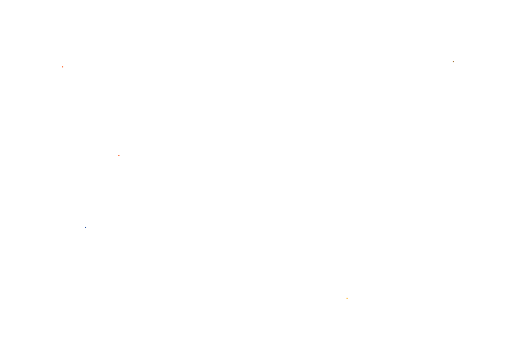

In [161]:
# Let's see what someone's placements from this list looks like

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, x2, y2,
        pixel_color
    FROM
        '{PARQUET_PATH}'
    WHERE
        user_id = 7644988 
"""

df = duckdb.query(query).df()
xmin, xmax = df['x1'].min() - 50, df['x1'].max() + 50
ymin, ymax = df['y1'].min() - 50, df['y1'].max() + 50
createGif(xmin, xmax, ymin, ymax, df, file=f"bot_test_0.gif", fps=30, dt=200)